In [3]:
import requests
import pandas as pd
import time
from datetime import date
from sklearn.linear_model import LinearRegression
from scipy.stats import f_oneway
from datetime import timedelta
import os

In [ ]:
tmdb_api_key = input("Enter TMDB API key: ")

In [5]:
DEFAULT_START_DATE = "2000-01-01"
END_DATE = "2025-12-31"


def get_movies(start_date=DEFAULT_START_DATE, end_date=END_DATE):
    tmdb_url = "https://api.themoviedb.org/3/discover/movie"
    all_movies = []
    page = 1

    while True:
        params = {
            "api_key": tmdb_api_key,
            "page": page,
            "primary_release_date.gte": start_date,
            "primary_release_date.lte": end_date,
            "sort_by": "primary_release_date.asc",
            "vote_count.gte": 1,
            "with_origin_country": "US",
        }

        try:
            response = requests.get(tmdb_url, params=params)
            response.raise_for_status()
            movie_data = response.json()
        except requests.exceptions.RequestException:
            break

        results = movie_data.get("results", [])
        if not results:
            break

        all_movies.extend(results)
        print(f"Fetched page {page}")

        total_pages = movie_data.get("total_pages", 1)
        if page >= total_pages or page >= 5:
            break

        page += 1

    return all_movies

In [6]:
def get_movie_info(movie_id):
    url = f"https://api.themoviedb.org/3/movie/{movie_id}"
    params = {"api_key": tmdb_api_key, "append_to_response": "credits"}

    try:
        response = requests.get(url, params=params)
        response.raise_for_status()
        info_get = response.json()
    except requests.exceptions.RequestException:
        return None

    if (info_get.get("budget") or 0) == 0 or (info_get.get("revenue") or 0) == 0:
        return None

    return {
        "tmdb_id": movie_id,
        "title": info_get.get("title"),
        "release_date": info_get.get("release_date"),
        "runtime": info_get.get("runtime"),
        "budget": info_get.get("budget") or 0,
        "revenue": info_get.get("revenue") or 0,
        "cast": [c["name"] for c in info_get.get("credits", {}).get("cast", [])[:10]],
        "crew": [c["name"] for c in info_get.get("credits", {}).get("crew", [])[:10]],
        "countries": [
            c["iso_3166_1"] for c in info_get.get("production_countries", [])
        ],
        "status": info_get.get("status"),
        "overview": info_get.get("overview"),
        "popularity": info_get.get("popularity"),
        "vote_average": info_get.get("vote_average"),
        "vote_count": info_get.get("vote_count"),
        "tagline": info_get.get("tagline"),
        "genres": [g["name"] for g in info_get.get("genres", [])],
        "production_companies": [
            c["name"] for c in info_get.get("production_companies", [])
        ],
    }

In [10]:
def get_resume_start_date(output_path):
    if not os.path.exists(output_path):
        return DEFAULT_START_DATE

    existing_df = pd.read_csv(output_path)

    if existing_df.empty or "release_date" not in existing_df.columns:
        return DEFAULT_START_DATE

    existing_df["release_date"] = pd.to_datetime(
        existing_df["release_date"], errors="coerce"
    )

    latest_date = existing_df["release_date"].max()

    if pd.isna(latest_date):
        return DEFAULT_START_DATE

    next_date = latest_date + timedelta(days=1)
    return next_date.strftime("%Y-%m-%d")


def main():
    output_path = "../data/tmdb_movies.csv"

    start_date = get_resume_start_date(output_path)
    print(f"Starting from: {start_date}")

    dataset = []

    for movie in get_movies(start_date=start_date, end_date=END_DATE):
        movie_id = movie["id"]
        details = get_movie_info(movie_id)
        time.sleep(0.0001)

        print(f"Processing movie {movie_id}")

        if details:
            dataset.append(details)

    if not dataset:
        print("No new movies found.")
        return pd.DataFrame()

    df = pd.DataFrame(dataset)

    if os.path.exists(output_path):
        df.to_csv(output_path, mode="a", header=False, index=False)
    else:
        df.to_csv(output_path, index=False)

    print(f"Added {len(df)} rows to {output_path}")
    return df


if __name__ == "__main__":
    df = main()

Starting from: 2000-01-25
Fetched page 1
Fetched page 2
Fetched page 3
Fetched page 4
Fetched page 5
Processing movie 687173
Processing movie 493515


KeyboardInterrupt: 

In [8]:
# df = df.drop_duplicates(subset=["tmdb_id"])
# df = df[(df["budget"] > 0) & (df["revenue"] > 0)]
# df = df[df["countries"].apply(lambda x: isinstance(x, list) and "US" in x)]

In [9]:
df_cpi = pd.read_excel("historical-cpi-u-202603.xlsx", skiprows=3)

df_cpi = df_cpi.drop(columns=["Indent Level"])

df_cpi.columns = [
    "year",
    "jan",
    "feb",
    "mar",
    "apr",
    "may",
    "jun",
    "jul",
    "aug",
    "sep",
    "oct",
    "nov",
    "dec",
]

df_cpi["year"] = pd.to_numeric(df_cpi["year"], errors="coerce")
df_cpi = df_cpi.dropna(subset=["year"])

month_cols = df_cpi.columns[1:]
df_cpi[month_cols] = df_cpi[month_cols].apply(pd.to_numeric, errors="coerce")

df_cpi = df_cpi[(df_cpi["year"] >= 2000) & (df_cpi["year"] <= 2026)]

df_cpi["cpi"] = df_cpi[month_cols].mean(axis=1)

df_cpi = df_cpi[["year", "cpi"]]

df["release_year"] = pd.to_datetime(df["release_date"], errors="coerce").dt.year

df = df.merge(df_cpi, left_on="release_year", right_on="year", how="left")

df = df[df["cpi"].notna()]

base_cpi = df_cpi.loc[df_cpi["year"] == 2025, "cpi"].iloc[0]

df["budget_adj"] = df["budget"] * (base_cpi / df["cpi"])
df["revenue_adj"] = df["revenue"] * (base_cpi / df["cpi"])

df["roi_adj"] = (df["revenue_adj"] - df["budget_adj"]) / df["budget_adj"]

print(df[["budget", "budget_adj", "revenue", "revenue_adj"]].head())
print("Missing CPI values:", df["cpi"].isna().sum())

FileNotFoundError: [Errno 2] No such file or directory: 'historical-cpi-u-202603.xlsx'

In [ ]:
df = df[df["cpi"].notna()]
df = df[df["budget_adj"] > 0]
df = df[df["revenue_adj"] > 0]
df = df.dropna(subset=["roi_adj"])

## Data Overview

In [11]:
import pandas as pd

df = pd.read_csv("tmdb_movies.csv")
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year
df["budget_adj"] = df["budget"]
df["revenue_adj"] = df["revenue"]
df["roi_adj"] = (df["revenue_adj"] - df["budget_adj"]) / df["budget_adj"]

print(f"Loaded {len(df)} movies")

Loaded 5267 movies


## Simple Data Overview

In [ ]:
# Table: Rows represent a movie and each feature of the movie is being shown as a distinct column 

# Number of movies, columns
num_movies, num_columns = df.shape
print(f"Dataset: {num_movies} movies, {num_columns} columns")
print()

# columns and its data type
print("Columns and the data type:")
print(df.dtypes)

# Columns with missing data 
missing = df.isnull().sum()
print(f"Missing values: {missing}")
#just tagline and overview missing

# Test of 5 movies, using just 5 features for now to simplify visually
print("5 sample films:")
display(df[["title", "release_date", "budget_adj", "revenue_adj", "roi_adj", "genres"]].head())

Dataset: 5267 movies, 21 columns

Columns and the data type:
tmdb_id                          int64
title                           object
release_date            datetime64[ns]
runtime                          int64
budget                           int64
revenue                          int64
cast                            object
crew                            object
countries                       object
status                          object
overview                        object
popularity                     float64
vote_average                   float64
vote_count                       int64
tagline                         object
genres                          object
production_companies            object
release_year                     int32
budget_adj                       int64
revenue_adj                      int64
roi_adj                        float64
dtype: object
Mising values: tmdb_id                   0
title                     0
release_date              0
runtime

,title,release_date,budget_adj,revenue_adj,roi_adj,genres
0,The Dirt on Soap,2000-01-01,2883,2883,0.000000,"['Animation', 'Family']"
1,Passion of Mind,2000-01-07,12000000,769272,-0.935894,"['Drama', 'Romance']"
2,My Dog Skip,2000-01-12,6000000,35547761,4.924627,"['Comedy', 'Drama', 'Family']"
3,Next Friday,2000-01-12,11000000,59827328,4.438848,['Comedy']
4,Supernova,2000-01-14,90000000,14828081,-0.835244,"['Science Fiction', 'Horror', 'Thriller']"


## ROI Distribution

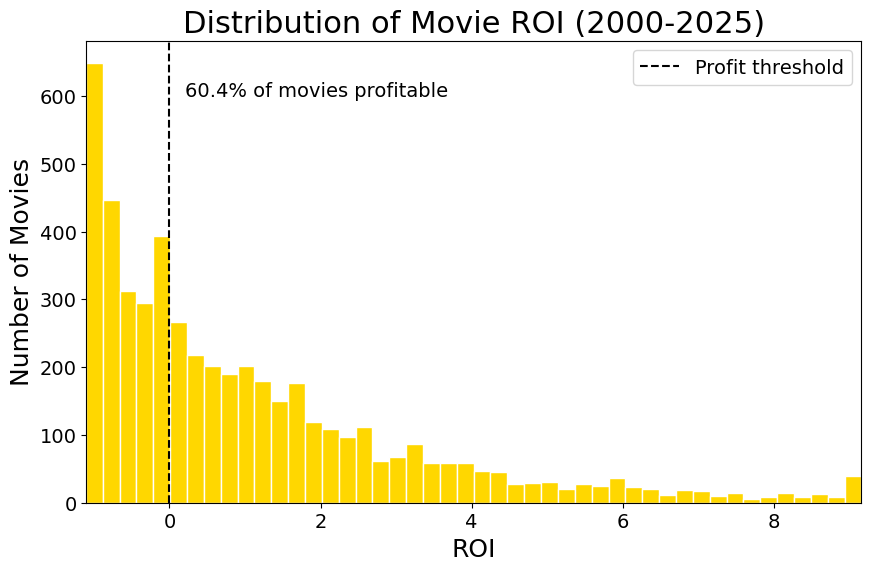

In [ ]:
import matplotlib.pyplot as plt


#Let me know if I should adjust the plot to make the x axis shorter in length! 

#Feel free to mess around with colors and stuff, picked gold for Hollywood??

#Also I made the font size and stuff bigger than normal since prof mentioned it a bunch during slide notes, feel free to alter too! 
roi_data = df[df["roi_adj"] <= df["roi_adj"].quantile(0.95)]["roi_adj"] #tweaking size for outliers
plt.figure(figsize=(10, 6))
plt.hist(roi_data, bins=50, color="gold", edgecolor="white")
plt.axvline(0, color="black", linestyle="--", label="Profit threshold")
plt.xlim(-1.1, roi_data.max()) #max loss is evidently -1 so starting plot there 
plt.title("Distribution of Movie ROI (2000-2025)", fontsize=22)
plt.xlabel("ROI", fontsize=18)
plt.ylabel("Number of Movies", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.text(0.2, 600, "60.4% of movies profitable", fontsize=14, color="black") 
# wanted to put this line ^ above since the distribution is a bit deceiving but not needed if you guys think it's overkill 
plt.show()

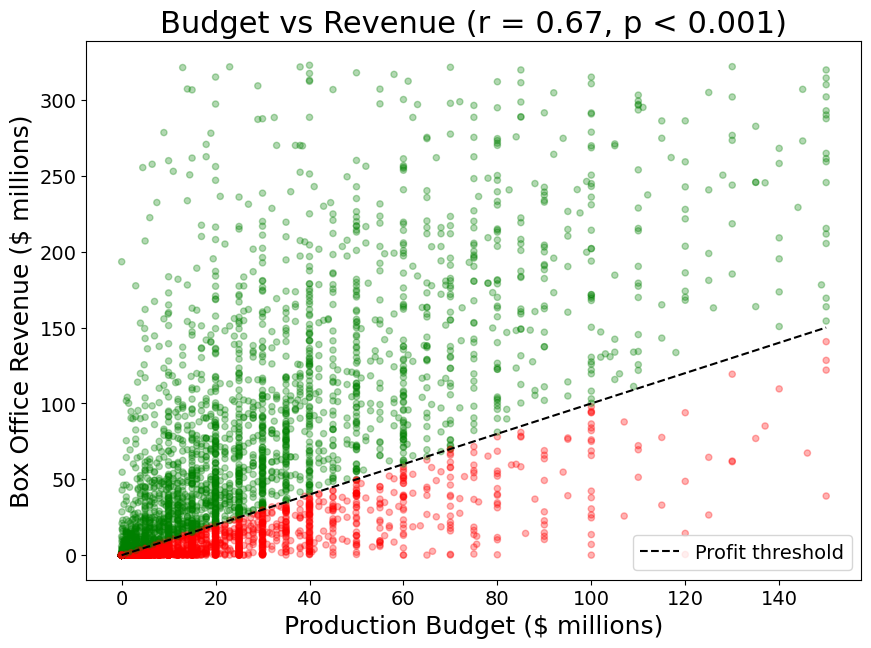

In [17]:
import matplotlib.pyplot as plt
from scipy import stats

# looks a little funky at parts due to the rounding of some of the production budgets ;/

# debating whether to put red/green label legend, but fear it may congest the screen too much?

# visually doesn't show the loss-making movies since they clump at bottom so much 

plot_df = df[df["revenue_adj"] > 0].copy() #removed the Some Bears movie that had a -12
plot_df = plot_df[plot_df["budget_adj"] <= plot_df["budget_adj"].quantile(0.95)] #removing crazy expensive movies/outliers
plot_df = plot_df[plot_df["revenue_adj"] <= plot_df["revenue_adj"].quantile(0.95)] #removing crazy expensive movies/outliers

# Correlation
r, p = stats.pearsonr(plot_df["budget_adj"], plot_df["revenue_adj"])

# Color by profit or loss
colors = plot_df["roi_adj"].apply(lambda x: "green" if x > 0 else "red")

plt.figure(figsize=(10, 7))
plt.scatter(
    plot_df["budget_adj"] / 1000000,
    plot_df["revenue_adj"] / 1000000,
    alpha=0.3, # was having trouble settling on alpha/opacity to try to best see clumps.. feel free to mess around with it! 
    c=colors,
    s=20
)

# profit threshold line
max_val = plot_df["budget_adj"].max() / 1000000
plt.plot([0, max_val], [0, max_val], "k--", linewidth=1.5, label="Profit threshold")

plt.title(f"Budget vs Revenue (r = {r:.2f}, p < 0.001)", fontsize=22)
plt.xlabel("Production Budget ($ millions)", fontsize=18)
plt.ylabel("Box Office Revenue ($ millions)", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)
plt.show()